In [1]:
import tensorflow as tf
from  tensorflow.keras.datasets  import  cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from  tensorflow.keras.optimizers  import  Adam, SGD
from  tensorflow.keras.utils  import  to_categorical
import matplotlib.pyplot as plt 
import numpy as np


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)


Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


In [3]:
# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0
# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


In [5]:
def create_cnn_model( filters1=32,
                     filters2=64,
                     kernel_size=(3,3), 
                     dropout_rate=0.5,
                     learning_rate=0.001, 
                     optimizer_type="adam"
):
    model = Sequential()
    model.add(Conv2D(filters1,  kernel_size,  activation='relu',input_shape=(32,32,3)))
    model.add(MaxPooling2D((2,2)))
    model.add(Conv2D(filters2, kernel_size, activation='relu'))
    model.add(MaxPooling2D((2,2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))
    if optimizer_type == "adam":
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = SGD(learning_rate=learning_rate, momentum=0.9)
    
    model.compile( optimizer=optimizer,loss='categorical_crossentropy', metrics=['accuracy'])
    return  model


In [6]:
baseline_model = create_cnn_model()
history_baseline = baseline_model.fit( x_train,y_train_cat, epochs=10, batch_size=64, validation_split=0.2)


D:\user\envs\tanubhalerao\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.3734 - loss: 1.7000 - val_accuracy: 0.5160 - val_loss: 1.3707
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.5023 - loss: 1.3837 - val_accuracy: 0.5578 - val_loss: 1.2610
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.5567 - loss: 1.2467 - val_accuracy: 0.6165 - val_loss: 1.1173
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.5879 - loss: 1.1710 - val_accuracy: 0.6204 - val_loss: 1.0726
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6111 - loss: 1.1056 - val_accuracy: 0.6519 - val_loss: 1.0153
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1422s 2s/step - accuracy: 0.6330 - loss: 1.0461 - val_accuracy: 0.6600 - val_loss: 0.9653
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.6466 - loss: 1.0025 - val_accuracy: 0.6626 - val_loss: 0.9664
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.6596 - loss: 0.9675 - 

In [7]:
baseline_loss, baseline_acc = baseline_model.evaluate(x_test, y_test_cat)
print("Baseline Test Accuracy:", baseline_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6938 - loss: 0.8948
Baseline Test Accuracy: 0.6937999725341797


In [8]:
optimized_model = create_cnn_model( filters1=64,
filters2=128, kernel_size=(3,3), dropout_rate=0.3, learning_rate=0.0005, optimizer_type="adam"
)
history_optimized = optimized_model.fit( x_train,
y_train_cat, epochs=15, batch_size=64, validation_split=0.2
)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 87ms/step - accuracy: 0.3860 - loss: 1.6850 - val_accuracy: 0.5159 - val_loss: 1.3879
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.5228 - loss: 1.3348 - val_accuracy: 0.5830 - val_loss: 1.1919
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.5742 - loss: 1.1922 - val_accuracy: 0.6210 - val_loss: 1.0845
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 88ms/step - accuracy: 0.6151 - loss: 1.0907 - val_accuracy: 0.6285 - val_loss: 1.0622
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 82ms/step - accuracy: 0.6438 - loss: 1.0194 - val_accuracy: 0.6608 - val_loss: 0.9814
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 89ms/step - accuracy: 0.6615 - loss: 0.9648 - val_accuracy: 0.6662 - val_loss: 0.9702
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1091s 2s/step - accuracy: 0.6852 - loss: 0.9032 - val_accuracy: 0.6702 - val_loss: 0.9320
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.7020 - loss: 0.8550 - 

In [10]:
opt_loss, opt_acc = optimized_model.evaluate(x_test, y_test_cat) 
print("Optimized Test Accuracy:", opt_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7087 - loss: 0.8801
Optimized Test Accuracy: 0.7087000012397766


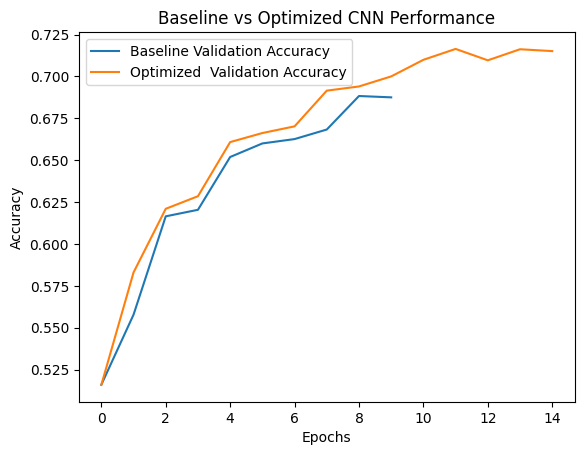

In [11]:
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Validation Accuracy')
plt.plot(history_optimized.history['val_accuracy'],  label='Optimized  Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Baseline vs Optimized CNN Performance") 
plt.show()
